In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

In [5]:
df = pd.read_csv('dectree.csv')
le = LabelEncoder()
df['Nationality']= le.fit_transform(df['Nationality'])
df['Go']=le.fit_transform(df['Go'])

df
df.head()

,Age,Experience,Rank,Nationality,Go
0,36,10,9,1,0
1,42,12,4,2,0
2,23,4,6,0,0
3,52,4,4,2,0
4,43,21,8,2,1


In [6]:
x = df.drop('Go',axis=1)
y = df['Go']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [9]:
logreg = LogisticRegression(random_state=16)
logreg.fit(x_train, y_train)

y_pred = logreg.predict(x_test)


In [10]:
accuracy_score(y_test, y_pred)
print(f'Classification Report: \n{classification_report(y_test, y_pred)}')

Classification Report: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      0.67      0.67         3

    accuracy                           0.50         4
   macro avg       0.33      0.33      0.33         4
weighted avg       0.50      0.50      0.50         4



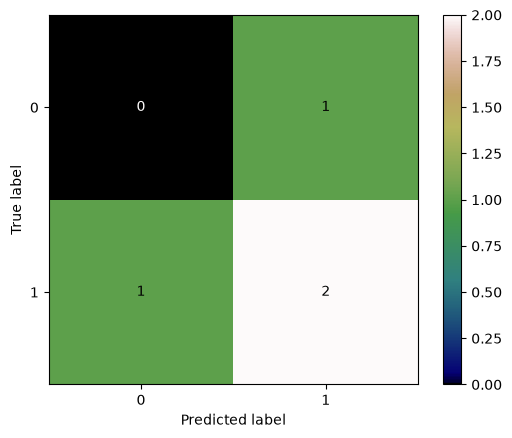

In [11]:
cf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    cmap=plt.cm.gist_earth
)